# LOSO Cross-Validation: SMOTE and outlier sensitivity

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import LeaveOneGroupOut, GroupKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, f1_score

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

os.makedirs('outputs', exist_ok=True)

PALETTE = {
    "PD":      "#E24B4A",
    "Healthy": "#378ADD",
    "SVM":     "#7F77DD",
    "HGB":     "#1D9E75",
    "LR":      "#BA7517",
    "RF":      "#B07FC8",
    "All":     "#D4537E",
    "JS":      "#639922",
}
OUTLIER_COLOR = {
    "With outliers":    "#60a5fa",  
    "Without outliers": "#f97316",  
}

plt.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "sans-serif",
    "axes.spines.top":   False,
    "axes.spines.right": False,
})
sns.set_style("whitegrid")

## Load Data

In [13]:
train_a = pd.read_csv('../data/train_a.csv')
test_a  = pd.read_csv('../data/test_a.csv')
train_b = pd.read_csv('../data/train_b.csv')
test_b  = pd.read_csv('../data/test_b.csv')

full_a = pd.concat([train_a, test_a], ignore_index=True)
full_b = pd.concat([train_b, test_b], ignore_index=True)

feature_cols = [c for c in full_a.columns if c not in ('name', 'status')]
JITTER_SHIMMER = [
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
    'MDVP:APQ', 'Shimmer:DDA',
]

for df in [full_a, full_b]:
    df['subject'] = df['name'].str.rsplit('_', n=1).str[0]

print(f'Dataset A: {len(full_a)} recordings, {full_a["subject"].nunique()} subjects')
print(f'Dataset B: {len(full_b)} recordings, {full_b["subject"].nunique()} subjects')
print(f'Status A:  {full_a["status"].value_counts().sort_index().to_dict()}  (0=Healthy, 1=PD)')

Dataset A: 195 recordings, 32 subjects
Dataset B: 187 recordings, 32 subjects
Status A:  {0.0: 48, 1.0: 147}  (0=Healthy, 1=PD)


## Outlier Flagging

Identical IQR method from `outlier_analysis.ipynb`.

In [14]:
def flag_iqr_outliers(df, feat_cols, threshold=3):
    """
    Returns a boolean Series: True where a recording is an IQR outlier
    in >= `threshold` features.  Matches outlier_analysis.ipynb exactly.
    """
    def iqr_flag(series):
        Q1, Q3 = series.quantile(0.25), series.quantile(0.75)
        IQR = Q3 - Q1
        return (series < Q1 - 1.5 * IQR) | (series > Q3 + 1.5 * IQR)

    flags = pd.DataFrame({f: iqr_flag(df[f]) for f in feat_cols}, index=df.index)
    return flags.sum(axis=1) >= threshold


for ds_label, df_full in [('A', full_a), ('B', full_b)]:
    outlier_mask = flag_iqr_outliers(df_full, feature_cols, threshold=3)
    df_full['is_outlier'] = outlier_mask

    n_total   = len(df_full)
    n_out     = outlier_mask.sum()
    n_clean   = n_total - n_out
    subj_aff  = df_full.loc[outlier_mask, 'subject'].nunique()

    print(f'Dataset {ds_label}:')
    print(f'  Total recordings : {n_total}')
    print(f'  Flagged outliers : {n_out}  ({n_out/n_total*100:.1f}%)  '
          f'across {subj_aff} subjects')
    print(f'  Clean recordings : {n_clean}')
    pd_out  = df_full.loc[outlier_mask, 'status'].sum()
    hlt_out = (df_full.loc[outlier_mask, 'status'] == 0).sum()
    print(f'  Outlier breakdown: {int(pd_out)} PD, {hlt_out} Healthy')
    print()

Dataset A:
  Total recordings : 195
  Flagged outliers : 17  (8.7%)  across 5 subjects
  Clean recordings : 178
  Outlier breakdown: 17 PD, 0 Healthy

Dataset B:
  Total recordings : 187
  Flagged outliers : 16  (8.6%)  across 5 subjects
  Clean recordings : 171
  Outlier breakdown: 16 PD, 0 Healthy



## LogTransformer

Unchanged from `loso_smote_evaluation.ipynb`.

In [15]:
SKEWED_FEATURES = [
    'MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)',
    'MDVP:Jitter(%)', 'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
    'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
    'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'PPE', 'spread1', 'D2',
]


class LogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, skewed_cols, all_cols):
        self.skewed_cols = skewed_cols
        self.all_cols    = all_cols

    def fit(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols)
        self.mins_    = {c: df[c].min()             for c in self.skewed_cols}
        self.use_log_ = {c: bool((df[c] > 0).all()) for c in self.skewed_cols}
        return self

    def transform(self, X, y=None):
        df = pd.DataFrame(X, columns=self.all_cols).copy()
        for c in self.skewed_cols:
            if self.use_log_[c]:
                df[c] = np.log(df[c])
            else:
                df[c] = np.log1p(df[c] - self.mins_[c])
        return df.values

## LOSO Evaluation Function

Unchanged from `loso_smote_evaluation.ipynb`.

In [16]:
def loso_evaluate(pipe, param_grid, X, y, groups,
                  inner_k=5, scoring='balanced_accuracy'):
    logo = LeaveOneGroupOut()
    ba_scores, f1_scores = [], []

    for train_idx, test_idx in logo.split(X, y, groups):
        X_tr, X_te = X[train_idx], X[test_idx]
        y_tr, y_te = y[train_idx], y[test_idx]
        g_tr       = groups[train_idx]

        n_inner  = min(inner_k, len(np.unique(g_tr)))
        inner_cv = GroupKFold(n_splits=n_inner)

        gs = GridSearchCV(pipe, param_grid, cv=inner_cv,
                          scoring=scoring, n_jobs=-1, refit=True)
        gs.fit(X_tr, y_tr, groups=g_tr)

        y_pred = gs.predict(X_te)
        ba_scores.append(balanced_accuracy_score(y_te, y_pred))
        f1_scores.append(f1_score(y_te, y_pred, average='macro', zero_division=0))

    return np.array(ba_scores), np.array(f1_scores)

## Model Pipelines and Hyperparameter Grids

Unchanged from `loso_smote_evaluation.ipynb`.

In [17]:
def make_svm(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = ImbPipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42)),
        ('svm',    SVC(kernel='rbf', random_state=42)),
    ])
    grid = {'svm__C': [0.1, 1, 10, 100], 'svm__gamma': ['scale', 'auto']}
    return pipe, grid


def make_lr(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = ImbPipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42)),
        ('lr',     LogisticRegression(penalty='l1', solver='liblinear',
                                      random_state=42, max_iter=1000)),
    ])
    grid = {'lr__C': np.logspace(-3, 3, 10)}
    return pipe, grid


def make_hgb():
    pipe = ImbPipeline([
        ('smote', SMOTE(random_state=42)),
        ('hgb',   HistGradientBoostingClassifier(
            random_state=42,
            early_stopping=True, validation_fraction=0.15, n_iter_no_change=20,
        )),
    ])
    grid = {
        'hgb__learning_rate':    [0.03, 0.05, 0.08, 0.1],
        'hgb__max_iter':         [100, 200, 300],
        'hgb__max_leaf_nodes':   [5, 10, 15, 20, 31],
        'hgb__l2_regularization':[0.0, 0.01, 0.1, 1.0],
        'hgb__min_samples_leaf': [5, 10, 20],
    }
    return pipe, grid


def make_rf(feat_cols):
    skewed = [c for c in SKEWED_FEATURES if c in feat_cols]
    pipe = ImbPipeline([
        ('log',    LogTransformer(skewed_cols=skewed, all_cols=feat_cols)),
        ('scaler', StandardScaler()),
        ('smote',  SMOTE(random_state=42)),
        ('rf',     RandomForestClassifier(random_state=42)),
    ])
    grid = {
        'rf__n_estimators':     [100, 200],
        'rf__max_depth':        [None, 10, 20],
        'rf__min_samples_leaf': [1, 5],
    }
    return pipe, grid

## LOSO Run — SMOTE × Outlier Conditions

The loop adds one extra dimension: each dataset is evaluated twice,
once with all recordings and once with outlier recordings removed.

Results saved to `outputs/loso_smote_outlier_results.csv`. Delete to re-run.

In [18]:
import time

OUT_CSV = 'outputs/loso_smote_outlier_results.csv'

if os.path.exists(OUT_CSV):
    print(f'Found {OUT_CSV}: loading existing results. Delete file to re-run.')
    df_loso = pd.read_csv(OUT_CSV)
    display(df_loso)
else:
    datasets = {'A': full_a, 'B': full_b}
    feat_configs = {
        'All features':   feature_cols,
        'Jitter+Shimmer': JITTER_SHIMMER,
    }
    # Outlier conditions: label → filter applied to the dataset
    outlier_configs = {
        'With outliers':    lambda df: df,
        'Without outliers': lambda df: df[~df['is_outlier']].reset_index(drop=True),
    }

    loso_rows = []
    t0 = time.time()

    for ds_key, df_full in datasets.items():
        for outlier_label, filter_fn in outlier_configs.items():
            df_use = filter_fn(df_full)
            y      = df_use['status'].values.astype(int)
            groups = df_use['subject'].values

            n_rec  = len(df_use)
            n_subj = len(np.unique(groups))
            print(f'\nDataset {ds_key} | {outlier_label} '
                  f'({n_rec} recordings, {n_subj} subjects)')

            for feat_label, fc in feat_configs.items():
                X = df_use[fc].values

                for model_label, make_fn in [
                    ('SVM', lambda: make_svm(fc)),
                    ('LR',  lambda: make_lr(fc)),
                    ('RF',  lambda: make_rf(fc)),
                    ('HGB', lambda: make_hgb()),
                ]:
                    print(f'  [{model_label}] {feat_label} ...', flush=True, end=' ')
                    t1 = time.time()
                    pipe, grid = make_fn()
                    ba, f1 = loso_evaluate(pipe, grid, X, y, groups)
                    elapsed = time.time() - t1
                    print(f'BA={ba.mean():.3f}±{ba.std():.3f}  '
                          f'F1={f1.mean():.3f}±{f1.std():.3f}  '
                          f'[{elapsed/60:.1f}min]')
                    loso_rows.append({
                        'Model':    model_label,
                        'Dataset':  ds_key,
                        'Features': feat_label,
                        'Outliers': outlier_label,
                        'BA_mean':  round(ba.mean(), 3),
                        'BA_std':   round(ba.std(),  3),
                        'F1_mean':  round(f1.mean(), 3),
                        'F1_std':   round(f1.std(),  3),
                        'n_folds':  len(ba),
                    })

    df_loso = pd.DataFrame(loso_rows)
    df_loso.to_csv(OUT_CSV, index=False)
    print(f'\nTotal runtime: {(time.time()-t0)/60:.1f} min')
    print(f'Saved: {OUT_CSV}')
    display(df_loso)

Found outputs/loso_smote_outlier_results.csv: loading existing results. Delete file to re-run.


,Model,Dataset,Features,Outliers,BA_mean,BA_std,F1_mean,F1_std,n_folds
0,SVM,A,All features,With outliers,0.714,0.369,0.596,0.387,32
1,LR,A,All features,With outliers,0.690,0.358,0.575,0.376,32
2,RF,A,All features,With outliers,0.745,0.368,0.655,0.393,32
3,HGB,A,All features,With outliers,0.740,0.373,0.653,0.393,32
4,SVM,A,Jitter+Shimmer,With outliers,0.619,0.418,0.565,0.426,32
5,LR,A,Jitter+Shimmer,With outliers,0.656,0.392,0.604,0.410,32
6,RF,A,Jitter+Shimmer,With outliers,0.684,0.345,0.593,0.376,32
7,HGB,A,Jitter+Shimmer,With outliers,0.685,0.297,0.573,0.342,32
8,SVM,A,All features,Without outliers,0.648,0.409,0.542,0.409,30
9,LR,A,All features,Without outliers,0.668,0.363,0.546,0.372,30


## Results Table

In [19]:
df_loso = pd.read_csv('outputs/loso_smote_outlier_results.csv')

df_loso['BA'] = df_loso.apply(lambda r: f"{r.BA_mean:.3f} ± {r.BA_std:.3f}", axis=1)
df_loso['F1'] = df_loso.apply(lambda r: f"{r.F1_mean:.3f} ± {r.F1_std:.3f}", axis=1)

pivot = df_loso.pivot_table(
    index=['Model', 'Dataset', 'Outliers'],
    columns='Features',
    values=['BA', 'F1'],
    aggfunc='first'
)
display(pivot)

BA                            F1  \
Features                         All features Jitter+Shimmer   All features   
Model Dataset Outliers                                                        
HGB   A       With outliers     0.740 ± 0.373  0.685 ± 0.297  0.653 ± 0.393   
              Without outliers  0.756 ± 0.370  0.598 ± 0.357  0.677 ± 0.392   
      B       With outliers     0.725 ± 0.370  0.659 ± 0.355  0.616 ± 0.388   
              Without outliers  0.751 ± 0.375  0.691 ± 0.326  0.674 ± 0.395   
LR    A       With outliers     0.690 ± 0.358  0.656 ± 0.392  0.575 ± 0.376   
              Without outliers  0.668 ± 0.363  0.621 ± 0.384  0.546 ± 0.372   
      B       With outliers     0.710 ± 0.357  0.642 ± 0.397  0.599 ± 0.378   
              Without outliers  0.692 ± 0.361  0.611 ± 0.379  0.573 ± 0.375   
RF    A       With outliers     0.745 ± 0.368  0.684 ± 0.345  0.655 ± 0.393   
              Without outliers  0.723 ± 0.379  0.691 ± 0.353  0.629 ± 0.397   
      B       With outliers     0.709 ± 0.382  0.654 ± 0.360  0.623 ± 0.402   
              Without outliers  0.711 ± 0.367  0.662 ± 0.362  0.611 ± 0.388   
SVM   A       With outliers     0.714 ± 0.369  0.619 ± 0.418  0.596 ± 0.387   
              Without outliers  0.648 ± 0.409  0.637 ± 0.384  0.542 ± 0.409   
      B       With outliers     0.674 ± 0.390  0.621 ± 0.417  0.577 ± 0.400   
              Without outliers  0.647 ± 0.401  0.626 ± 0.397  0.561 ± 0.411   

                                               
Features                       Jitter+Shimmer  
Model Dataset Outliers                         
HGB   A       With outliers     0.573 ± 0.342  
              Without outliers  0.505 ± 0.369  
      B       With outliers     0.582 ± 0.383  
              Without outliers  0.581 ± 0.360  
LR    A       With outliers     0.604 ± 0.410  
              Without outliers  0.506 ± 0.380  
      B       With outliers     0.581 ± 0.412  
              Without outliers  0.522 ± 0.384  
RF    A       With outliers     0.593 ± 0.376  
              Without outliers  0.609 ± 0.384  
      B       With outliers     0.563 ± 0.380  
              Without outliers  0.561 ± 0.381  
SVM   A       With outliers     0.565 ± 0.426  
              Without outliers  0.546 ± 0.395  
      B       With outliers     0.550 ± 0.421  
              Without outliers  0.555 ± 0.411

## Visualisation 

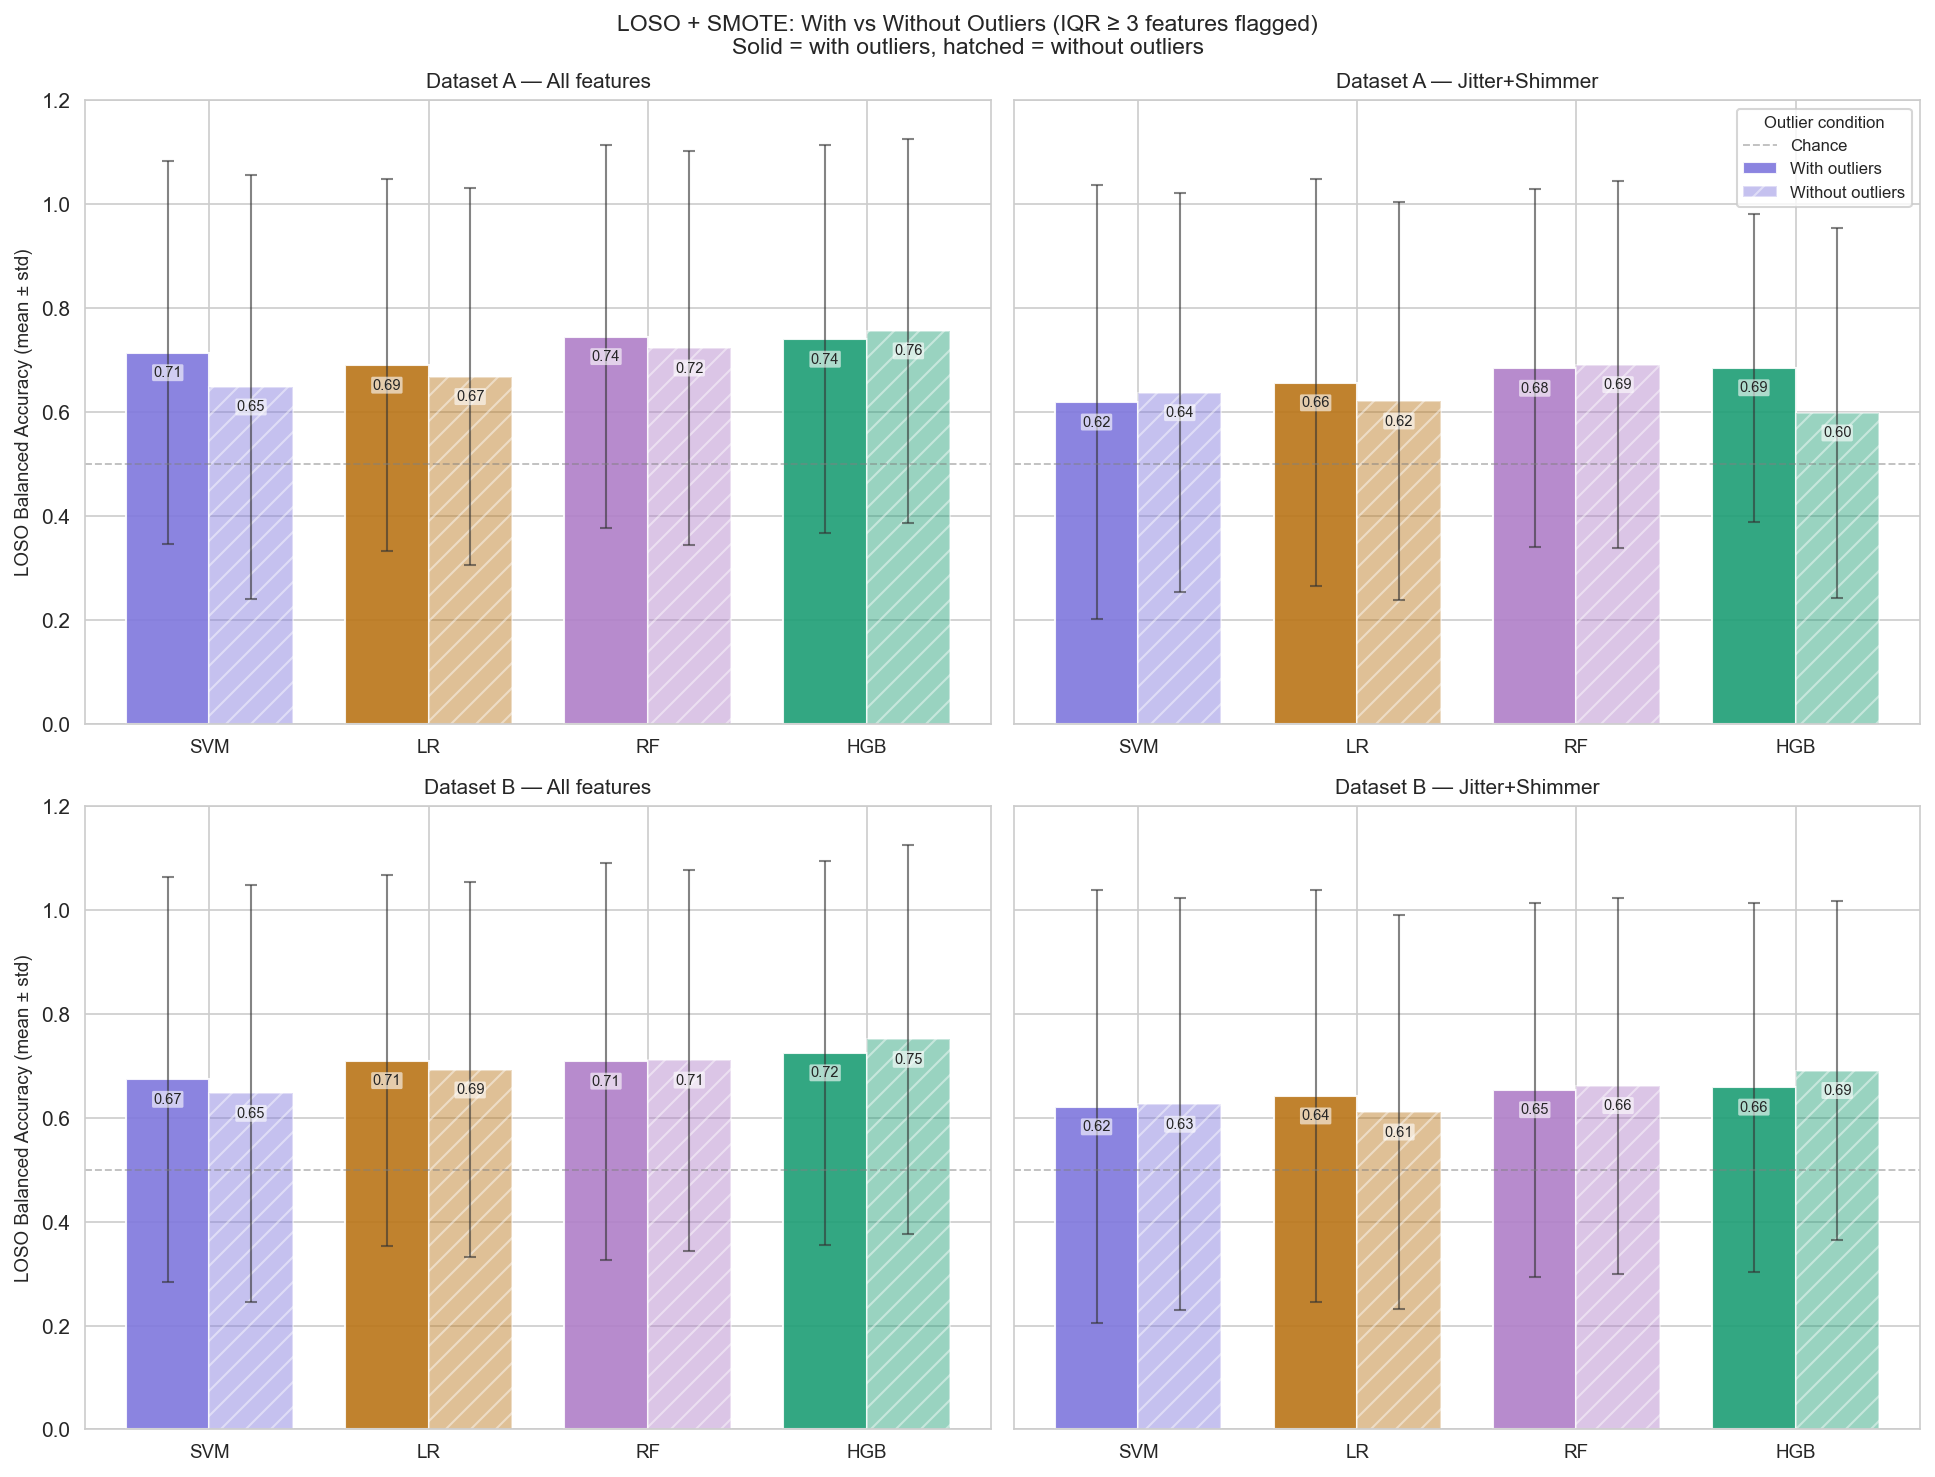

Saved: outputs/loso_smote_outlier_results.png


In [20]:
df_loso = pd.read_csv('outputs/loso_smote_outlier_results.csv')

model_order   = ['SVM', 'LR', 'RF', 'HGB']
feat_order    = ['All features', 'Jitter+Shimmer']
outlier_order = ['With outliers', 'Without outliers']
outlier_hatch = {'With outliers': '', 'Without outliers': '//'}

fig, axes = plt.subplots(2, 2, figsize=(13, 10), sharey=True)
x     = np.arange(len(model_order))
width = 0.38

for row, ds_key in enumerate(['A', 'B']):
    for col, feat_label in enumerate(feat_order):
        ax = axes[row][col]
        df_sub = df_loso[
            (df_loso['Dataset']  == ds_key) &
            (df_loso['Features'] == feat_label)
        ]

        for i, out_cond in enumerate(outlier_order):
            df_c   = df_sub[df_sub['Outliers'] == out_cond].set_index('Model')
            means  = [df_c.loc[m, 'BA_mean'] if m in df_c.index else 0 for m in model_order]
            stds   = [df_c.loc[m, 'BA_std']  if m in df_c.index else 0 for m in model_order]
            colors = [PALETTE[m] for m in model_order]
            offset = (i - 0.5) * width

            bars = ax.bar(
                x + offset, means, width,
                yerr=stds, capsize=3,
                error_kw=dict(elinewidth=1.0, ecolor='#333', alpha=0.6),
                color=colors, alpha=0.9 if out_cond == 'With outliers' else 0.45,
                hatch=outlier_hatch[out_cond],
                edgecolor='white', label=out_cond
            )
            for bar, mean in zip(bars, means):
                if mean > 0:
                    ax.text(
                        bar.get_x() + bar.get_width() / 2,
                        bar.get_height() - 0.025,
                        f'{mean:.2f}', ha='center', va='top', fontsize=7,
                        bbox=dict(boxstyle='round,pad=0.1', fc='white', alpha=0.6, ec='none')
                    )

        ax.axhline(0.5, color='grey', linestyle='--', lw=0.9, alpha=0.5, label='Chance')
        ax.set_xticks(x)
        ax.set_xticklabels(model_order, fontsize=9)
        ax.set_ylim(0, 1.2)
        ax.set_title(f'Dataset {ds_key} — {feat_label}', fontsize=10)
        if col == 0:
            ax.set_ylabel('LOSO Balanced Accuracy (mean ± std)', fontsize=9)
        if row == 0 and col == 1:
            ax.legend(fontsize=8, loc='upper right',
                      title='Outlier condition', title_fontsize=8)

fig.suptitle(
    'LOSO + SMOTE: With vs Without Outliers (IQR ≥ 3 features flagged)\n'
    'Solid = with outliers, hatched = without outliers',
    fontsize=11
)
plt.tight_layout()
plt.savefig('outputs/loso_smote_outlier_results.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: outputs/loso_smote_outlier_results.png')

## Delta Table

How much does removing outliers shift balanced accuracy?

In [21]:
df_loso = pd.read_csv('outputs/loso_smote_outlier_results.csv')

df_pivot = df_loso.pivot_table(
    index=['Model', 'Dataset', 'Features'],
    columns='Outliers',
    values='BA_mean'
).reset_index()

df_pivot.columns.name = None
df_pivot['Delta (Without − With)'] = (
    df_pivot['Without outliers'] - df_pivot['With outliers']
).round(3)
df_pivot = df_pivot.sort_values('Delta (Without − With)', key=abs, ascending=False)

print('BA delta when outliers are removed (positive = improves, negative = worsens):')
display(df_pivot.round(3))

# Flag any suspiciously large swings
large = df_pivot[df_pivot['Delta (Without − With)'].abs() > 0.05]
if len(large):
    print(f'\n{len(large)} condition(s) show |delta| > 0.05 — worth investigating:')
    display(large)
else:
    print('\nAll deltas ≤ 0.05: results are stable across outlier conditions.')

BA delta when outliers are removed (positive = improves, negative = worsens):


,Model,Dataset,Features,With outliers,Without outliers,Delta (Without − With)
1,HGB,A,Jitter+Shimmer,0.685,0.598,-0.087
12,SVM,A,All features,0.714,0.648,-0.066
5,LR,A,Jitter+Shimmer,0.656,0.621,-0.035
3,HGB,B,Jitter+Shimmer,0.659,0.691,0.032
7,LR,B,Jitter+Shimmer,0.642,0.611,-0.031
14,SVM,B,All features,0.674,0.647,-0.027
2,HGB,B,All features,0.725,0.751,0.026
4,LR,A,All features,0.690,0.668,-0.022
8,RF,A,All features,0.745,0.723,-0.022
6,LR,B,All features,0.710,0.692,-0.018



2 condition(s) show |delta| > 0.05 — worth investigating:


,Model,Dataset,Features,With outliers,Without outliers,Delta (Without − With)
1,HGB,A,Jitter+Shimmer,0.685,0.598,-0.087
12,SVM,A,All features,0.714,0.648,-0.066


## Full Comparison Across All Notebooks

In [22]:
files = {
    'Baseline':              'outputs/loso_results.csv',
    'SMOTE':                 'outputs/loso_smote_results.csv',
    'SMOTE + no outliers':   None,   
}

dfs = []
for label, path in files.items():
    if path and os.path.exists(path):
        df_tmp = pd.read_csv(path).assign(Condition=label)
        dfs.append(df_tmp)
    elif label == 'Baseline' or label == 'SMOTE':
        print(f'{path} not found —> skipping.')

# Add SMOTE + no outliers from this notebook's results
out_csv = 'outputs/loso_smote_outlier_results.csv'
if os.path.exists(out_csv):
    df_this = pd.read_csv(out_csv)
    for cond_label, outlier_val in [
        ('SMOTE + outliers',    'With outliers'),
        ('SMOTE + no outliers', 'Without outliers'),
    ]:
        dfs.append(
            df_this[df_this['Outliers'] == outlier_val]
                   .drop(columns=['Outliers'])
                   .assign(Condition=cond_label)
        )

if not dfs:
    print('No result files found yet. Run the notebooks first.')
else:
    df_all = pd.concat(dfs, ignore_index=True)

    summary = df_all.pivot_table(
        index=['Model', 'Features', 'Dataset'],
        columns='Condition',
        values='BA_mean',
        aggfunc='first'
    ).round(3)

    print('Balanced Accuracy across all conditions:')
    display(summary)

Balanced Accuracy across all conditions:


Condition                     Baseline  SMOTE  SMOTE + no outliers  \
Model Features       Dataset                                         
HGB   All features   A           0.730  0.740                0.756   
                     B           0.746  0.725                0.751   
      Jitter+Shimmer A           0.653  0.685                0.598   
                     B           0.584  0.659                0.691   
LR    All features   A           0.700  0.690                0.668   
                     B           0.673  0.710                0.692   
      Jitter+Shimmer A           0.666  0.656                0.621   
                     B           0.648  0.642                0.611   
RF    All features   A           0.771  0.745                0.723   
                     B           0.755  0.709                0.711   
      Jitter+Shimmer A           0.714  0.684                0.691   
                     B           0.685  0.654                0.662   
SVM   All features   A           0.714  0.714                0.648   
                     B           0.712  0.674                0.647   
      Jitter+Shimmer A           0.624  0.619                0.637   
                     B           0.641  0.621                0.626   

Condition                     SMOTE + outliers  
Model Features       Dataset                    
HGB   All features   A                   0.740  
                     B                   0.725  
      Jitter+Shimmer A                   0.685  
                     B                   0.659  
LR    All features   A                   0.690  
                     B                   0.710  
      Jitter+Shimmer A                   0.656  
                     B                   0.642  
RF    All features   A                   0.745  
                     B                   0.709  
      Jitter+Shimmer A                   0.684  
                     B                   0.654  
SVM   All features   A                   0.714  
                     B                   0.674  
      Jitter+Shimmer A                   0.619  
                     B                   0.621